In [2]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

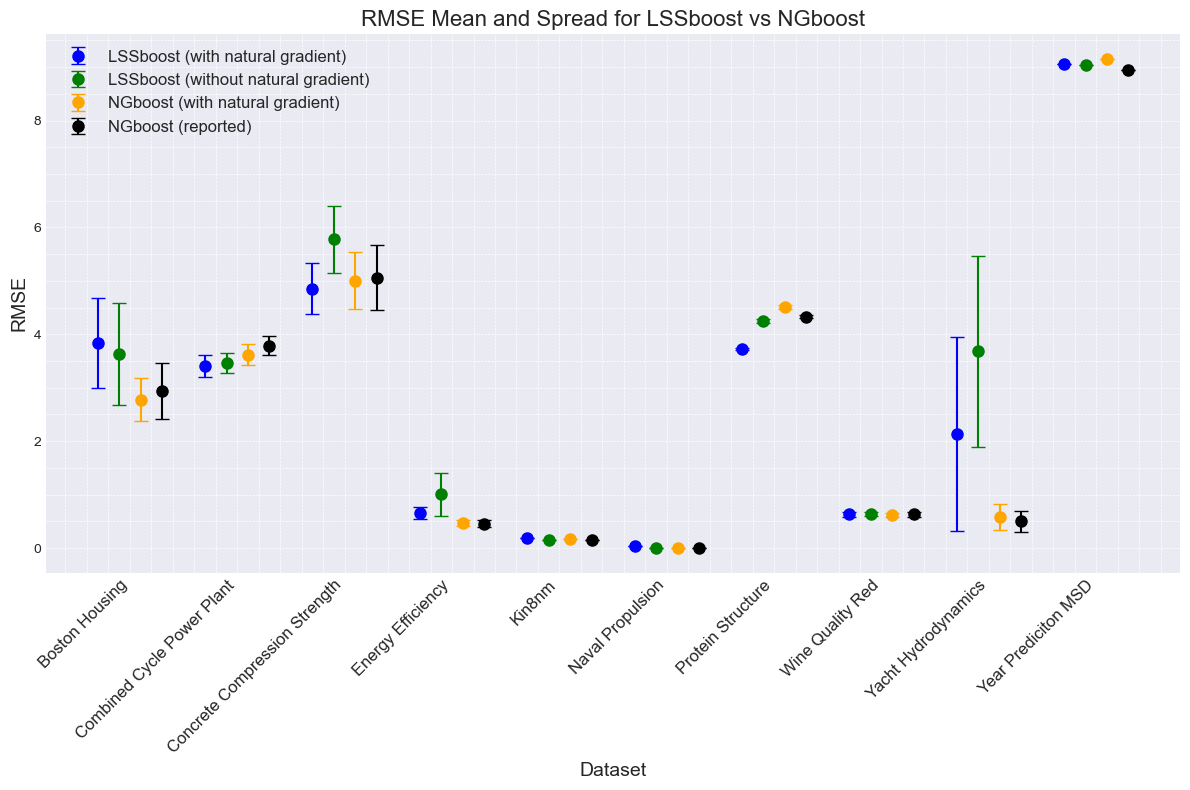

In [41]:
# Loading the data
df_lssboost = pd.read_csv('results/LSSboost_natural_HP_each_with_MSD_19_june.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_no_natural_HP_each_18_june.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_more_estimators.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset'])

df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True, how='outer')
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True, how='outer')
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True, how='outer')

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_RMSE-mean']
stds_lssboost = merged_df['lss_RMSE-std']
means_lssboost_nonatural = merged_df['lss_nonatural_RMSE-mean']
stds_lssboost_nonatural = merged_df['lss_nonatural_RMSE-std']
means_ngboost = merged_df['ngb_RMSE-mean']
stds_ngboost = merged_df['ngb_RMSE-std']
means_rep_ngboost = merged_df['rep_RMSE-mean']
stds_rep_ngboost = merged_df['rep_RMSE-std']

x = np.arange(len(datasets))  # the label locations

fig, ax = plt.subplots(figsize=(12, 8))
width = 0.2  # the width of the bars
dot_size = 8

# Plotting LSSboost means with error bars
ax.errorbar(x - 1.5*width, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost (with natural gradient)', markersize=dot_size)

# Plotting LSSboost nonatural means with error bars
ax.errorbar(x - 0.5*width, means_lssboost_nonatural, yerr=stds_lssboost_nonatural, fmt='o', color='green', ecolor='green', capsize=5, label='LSSboost (without natural gradient)', markersize=dot_size)

# Plotting NGboost means with error bars
ax.errorbar(x + 0.5*width, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (with natural gradient)', markersize=dot_size)

# Plotting NGboost reported means with error bars
ax.errorbar(x + 1.5*width, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Adding text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Dataset', fontsize=14)
ax.set_ylabel('RMSE', fontsize=14)
ax.set_title('RMSE Mean and Spread for LSSboost vs NGboost', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Adding grid and minor ticks
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.minorticks_on()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('images/RMSE_evaluation_probdist_improved.png')
plt.show()

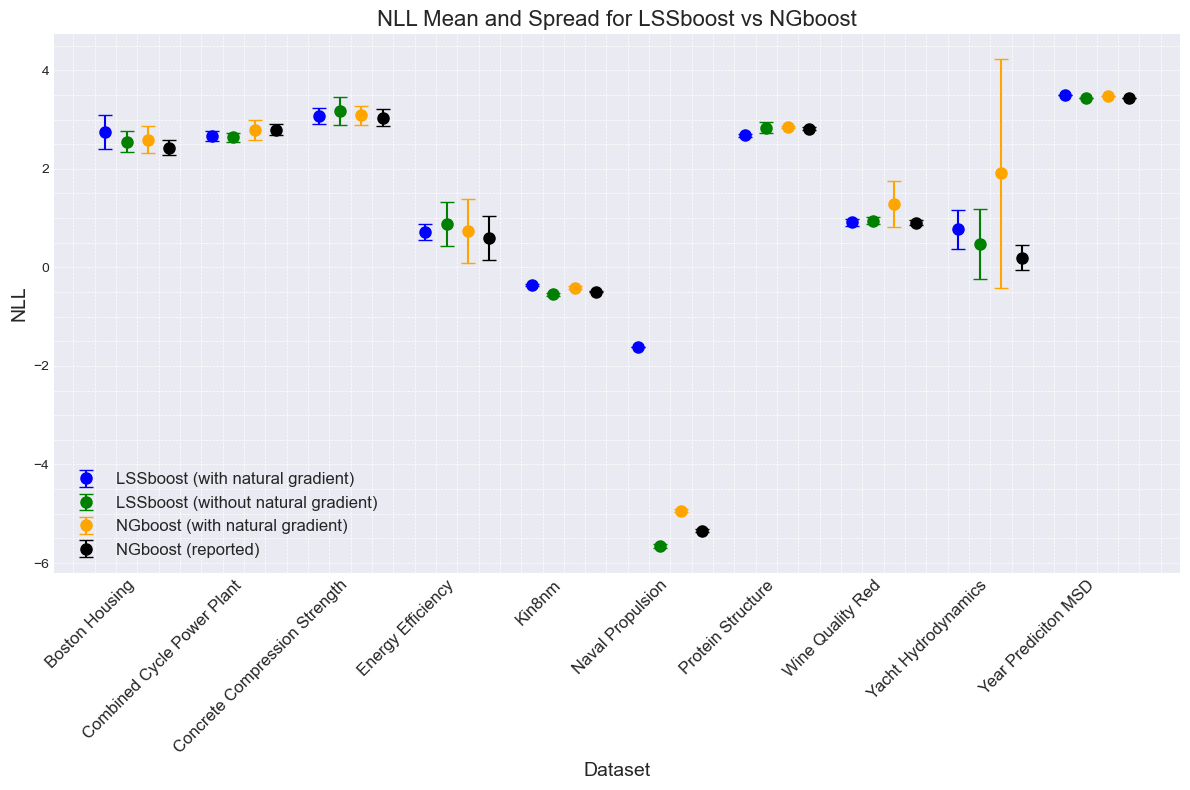

In [42]:
# Loading the data
df_lssboost = pd.read_csv('results/LSSboost_natural_HP_each_with_MSD_19_june.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_no_natural_HP_each_18_june.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_more_estimators.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset'])

df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True, how='outer')
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True, how='outer')
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True, how='outer')

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_NLL-mean']
stds_lssboost = merged_df['lss_NLL-std']
means_lssboost_nonatural = merged_df['lss_nonatural_NLL-mean']
stds_lssboost_nonatural = merged_df['lss_nonatural_NLL-std']
means_ngboost = merged_df['ngb_NLL-mean']
stds_ngboost = merged_df['ngb_NLL-std']
means_rep_ngboost = merged_df['rep_NLL-mean']
stds_rep_ngboost = merged_df['rep_NLL-std']

x = np.arange(len(datasets))  # the label locations

fig, ax = plt.subplots(figsize=(12, 8))
width = 0.2  # the width of the bars
dot_size = 8

# Plotting LSSboost means with error bars
ax.errorbar(x - 1.5*width, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost (with natural gradient)', markersize=dot_size)

# Plotting LSSboost nonatural means with error bars
ax.errorbar(x - 0.5*width, means_lssboost_nonatural, yerr=stds_lssboost_nonatural, fmt='o', color='green', ecolor='green', capsize=5, label='LSSboost (without natural gradient)', markersize=dot_size)

# Plotting NGboost means with error bars
ax.errorbar(x + 0.5*width, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (with natural gradient)', markersize=dot_size)

# Plotting NGboost reported means with error bars
ax.errorbar(x + 1.5*width, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Adding text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Dataset', fontsize=14)
ax.set_ylabel('NLL', fontsize=14)
ax.set_title('NLL Mean and Spread for LSSboost vs NGboost', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Adding grid and minor ticks
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.minorticks_on()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('images/NLL_evaluation_probdist_improved.png')
plt.show()

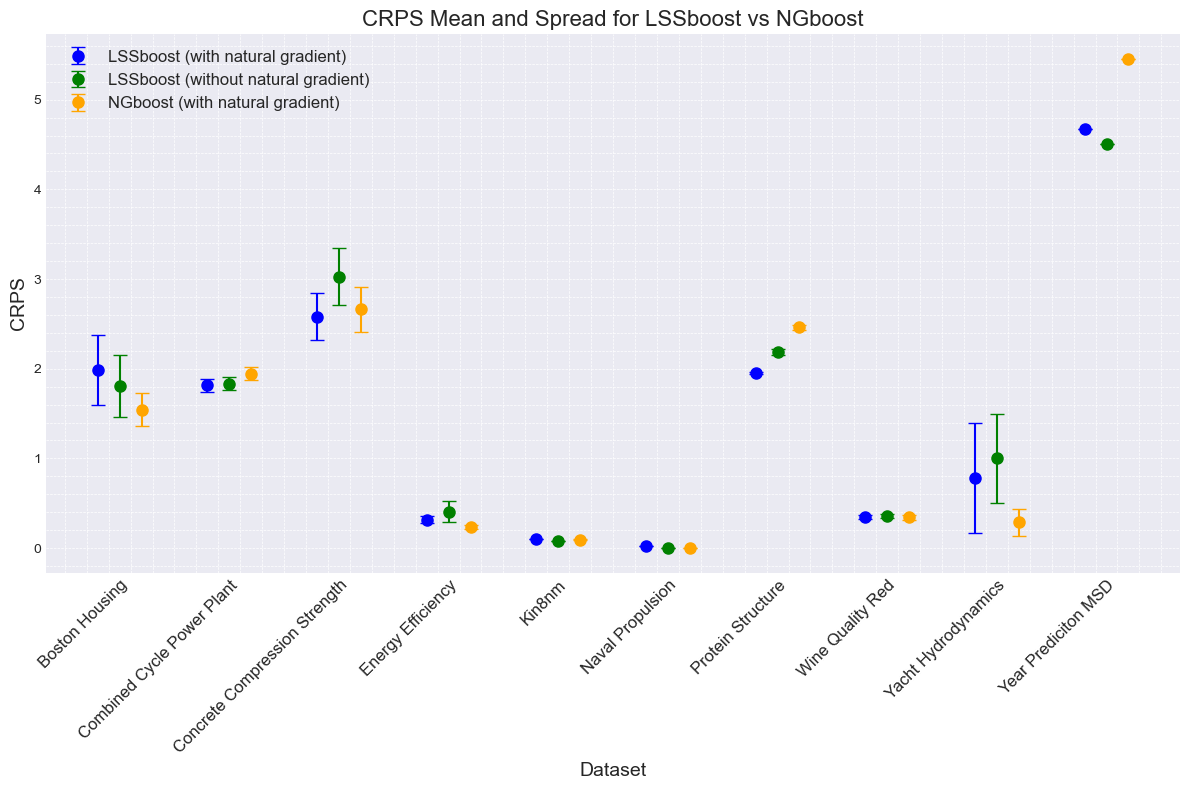

In [39]:
# Loading the data
df_lssboost = pd.read_csv('results/LSSboost_natural_HP_each_with_MSD_19_june.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_no_natural_HP_each_18_june.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_more_estimators.csv', index_col=['dset'])

df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True, how='outer')
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True, how='outer')

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_CRPS-mean']
stds_lssboost = merged_df['lss_CRPS-std']
means_lssboost_nonatural = merged_df['lss_nonatural_CRPS-mean']
stds_lssboost_nonatural = merged_df['lss_nonatural_CRPS-std']
means_ngboost = merged_df['ngb_CRPS-mean']
stds_ngboost = merged_df['ngb_CRPS-std']

x = np.arange(len(datasets))  # the label locations

fig, ax = plt.subplots(figsize=(12, 8))
width = 0.2  # the width of the bars
dot_size = 8

# Plotting LSSboost means with error bars
ax.errorbar(x - 1.5*width, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost (with natural gradient)', markersize=dot_size)

# Plotting LSSboost nonatural means with error bars
ax.errorbar(x - 0.5*width, means_lssboost_nonatural, yerr=stds_lssboost_nonatural, fmt='o', color='green', ecolor='green', capsize=5, label='LSSboost (without natural gradient)', markersize=dot_size)

# Plotting NGboost means with error bars
ax.errorbar(x + 0.5*width, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (with natural gradient)', markersize=dot_size)

# Adding text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Dataset', fontsize=14)
ax.set_ylabel('CRPS', fontsize=14)
ax.set_title('CRPS Mean and Spread for LSSboost vs NGboost', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Adding grid and minor ticks
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.minorticks_on()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('images/CRPS_evaluation_probdist_improved.png')
plt.show()

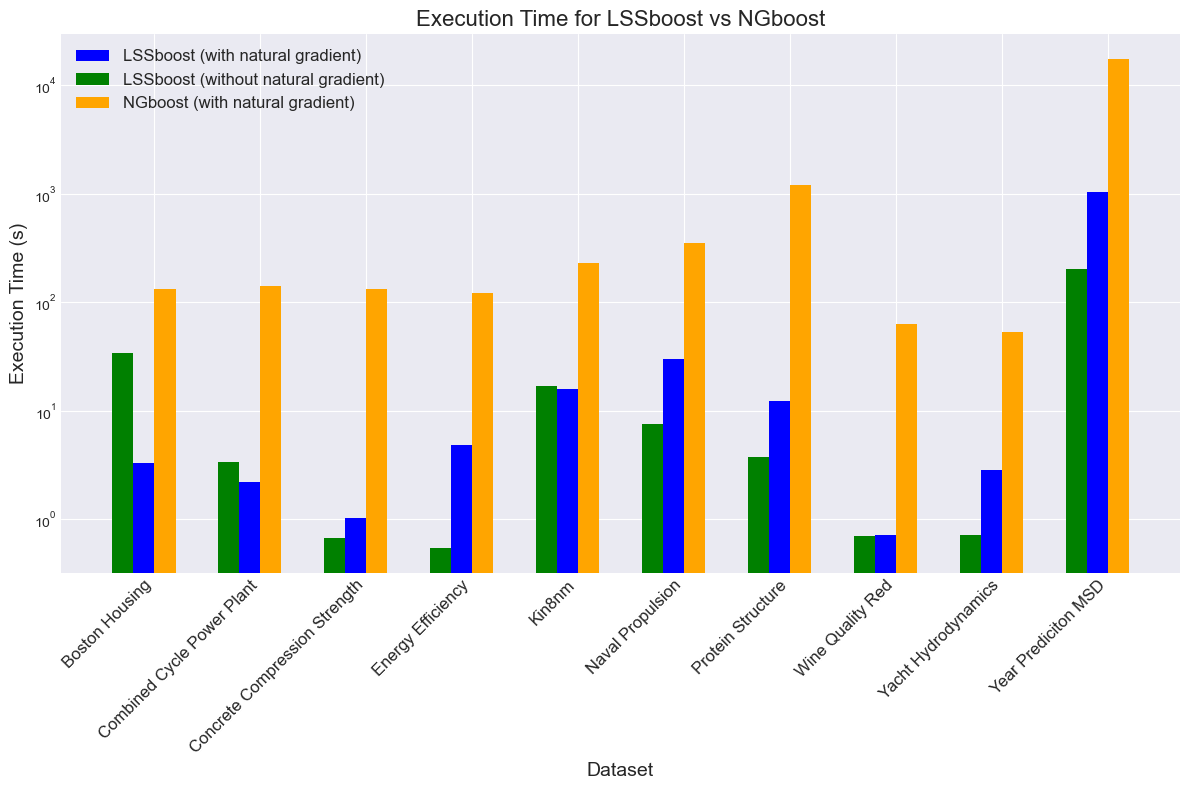

In [40]:
# Loading the data
df_lssboost = pd.read_csv('results/LSSboost_natural_HP_each_with_MSD_19_june.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_no_natural_HP_each_18_june.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_more_estimators.csv', index_col=['dset'])

df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True, how='outer')
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True, how='outer')

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_time']
means_lssboost_nonatural = merged_df['lss_nonatural_time']
means_ngboost = merged_df['ngb_time']

x = np.arange(len(datasets))  # the label locations

fig, ax = plt.subplots(figsize=(12, 8))
width = 0.2  # the width of the bars
dot_size = 8

# Plotting LSSboost and NGboost execution times
ax.bar(x - 0.5*width, means_lssboost, width, color='blue', label='LSSboost (with natural gradient)')
ax.bar(x - 1.5 * width, means_lssboost_nonatural, width, color='green', label='LSSboost (without natural gradient)')
ax.bar(x + 0.5*width, means_ngboost, width, color='orange', label='NGboost (with natural gradient)')

# Adding text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Dataset', fontsize=14)
ax.set_ylabel('Execution Time (s)', fontsize=14)
ax.set_title('Execution Time for LSSboost vs NGboost', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# make y-axis log scale
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('images/time_evaluation.png')
plt.show()


In [35]:
# Loading the data
df_lssboost = pd.read_csv('results/LSSboost_natural_HP_each_with_MSD_19_june.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_no_natural_HP_each_18_june.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_more_estimators.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset'])

# Adding prefixes for clarity
df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

# Merging the dataframes
merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True)

# Selecting and renaming columns for clarity
final_df = merged_df[['lss_RMSE-mean', 'lss_RMSE-std', 
                      'lss_nonatural_RMSE-mean', 'lss_nonatural_RMSE-std', 
                      'ngb_RMSE-mean', 'ngb_RMSE-std', 
                      'rep_RMSE-mean', 'rep_RMSE-std']]

final_df.columns = ['LSSboost (Natural) Mean', 'LSSboost (Natural) Std',
                    'LSSboost (No Natural) Mean', 'LSSboost (No Natural) Std',
                    'NGboost Mean', 'NGboost Std',
                    'NGboost Reported Mean', 'NGboost Reported Std']

# Creating a new dataframe for LaTeX formatted output
latex_df = pd.DataFrame(index=final_df.index)

latex_df['LSSboost (Natural)'] = final_df.apply(lambda row: f"{row['LSSboost (Natural) Mean']:.2f} ± {row['LSSboost (Natural) Std']:.2f}", axis=1)
latex_df['LSSboost (No Natural)'] = final_df.apply(lambda row: f"{row['LSSboost (No Natural) Mean']:.2f} ± {row['LSSboost (No Natural) Std']:.2f}", axis=1)
latex_df['NGboost'] = final_df.apply(lambda row: f"{row['NGboost Mean']:.2f} ± {row['NGboost Std']:.2f}", axis=1)
latex_df['NGboost Reported'] = final_df.apply(lambda row: f"{row['NGboost Reported Mean']:.2f} ± {row['NGboost Reported Std']:.2f}", axis=1)

# # Converting to LaTeX
latex_df

# save to xls 
latex_df.to_excel('results/rmse_table.xlsx')

In [36]:
# Loading the data
df_lssboost = pd.read_csv('results/LSSboost_natural_HP_each_with_MSD_19_june.csv', index_col=['dset'])
df_lssboost_nonatural = pd.read_csv('results/LSSboost_no_natural_HP_each_18_june.csv', index_col=['dset'])
df_ngboost = pd.read_csv('results/NGboost_natural_more_estimators.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset'])

# Adding prefixes for clarity
df_lssboost = df_lssboost.add_prefix('lss_')
df_lssboost_nonatural = df_lssboost_nonatural.add_prefix('lss_nonatural_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

# Merging the dataframes
merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)
merged_df = merged_df.merge(df_lssboost_nonatural, left_index=True, right_index=True)

# Selecting and renaming columns for clarity
final_df = merged_df[['lss_NLL-mean', 'lss_NLL-std', 
                      'lss_nonatural_NLL-mean', 'lss_nonatural_NLL-std', 
                      'ngb_NLL-mean', 'ngb_NLL-std', 
                      'rep_NLL-mean', 'rep_NLL-std']]

final_df.columns = ['LSSboost (Natural) Mean', 'LSSboost (Natural) Std',
                    'LSSboost (No Natural) Mean', 'LSSboost (No Natural) Std',
                    'NGboost Mean', 'NGboost Std',
                    'NGboost Reported Mean', 'NGboost Reported Std']

# Creating a new dataframe for LaTeX formatted output
latex_df = pd.DataFrame(index=final_df.index)

latex_df['LSSboost (Natural)'] = final_df.apply(lambda row: f"{row['LSSboost (Natural) Mean']:.2f} ± {row['LSSboost (Natural) Std']:.2f}", axis=1)
latex_df['LSSboost (No Natural)'] = final_df.apply(lambda row: f"{row['LSSboost (No Natural) Mean']:.2f} ± {row['LSSboost (No Natural) Std']:.2f}", axis=1)
latex_df['NGboost'] = final_df.apply(lambda row: f"{row['NGboost Mean']:.2f} ± {row['NGboost Std']:.2f}", axis=1)
latex_df['NGboost Reported'] = final_df.apply(lambda row: f"{row['NGboost Reported Mean']:.2f} ± {row['NGboost Reported Std']:.2f}", axis=1)

# # Converting to LaTeX
latex_df

# save to xls 
latex_df.to_excel('results/nll_table.xlsx')